Notebook to place a pattern on a FIB image

In [12]:
# general
from __future__ import annotations
from copy import deepcopy
import tempfile
import typing

# for display
import napari
import PIL
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire

# Adaptive polishing
from adaptive_polish import gis_measurement as gm

if typing.TYPE_CHECKING:
    from numpy.typing import NDArray, DTypeLike

In [3]:
base_path = Path.home() / "OneDrive - The Rosalind Franklin Institute" / "Documents" / "test data" / "adaptive milling" / "2024segmentation_testdata"
model_path = base_path / "2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp"
bitmaps_path = base_path / "plots" / "modified_GIS_m"
config_path = Path.cwd().parent.parent.parent.parent / "fibsem" / "fibsem" / "config" / "microscope-configuration-demo2.yaml"
protocol_path = Path.cwd() / "spoof_microscope_protocol.yaml"

PIXEL_SIZE_M = 1.3020833333333335e-08 # This is incorrect, get the pixel size from the image metadata instead!

In [4]:
gm.init_model_with_path(model_path=model_path)

In [5]:
# Set up test microscope
microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2025-01-06 18:34:15,228 — root — INFO — connect_to_microscope:5399 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2025-01-06 18:34:15,229 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2025-01-06-06-34-15PM


In [6]:
print(settings)

MicroscopeSettings(system=SystemSettings(stage=StageSystemSettings(rotation_reference=0, rotation_180=180, shuttle_pre_tilt=35.0, manipulator_height_limit=0.0037, enabled=True, rotation=True, tilt=True), electron=BeamSystemSettings(beam_type=<BeamType.ELECTRON: 1>, enabled=True, beam=BeamSettings(beam_type=<BeamType.ELECTRON: 1>, working_distance=0.007, beam_current=5e-11, voltage=2000, hfw=0.00015, resolution=[1536, 1024], dwell_time=1e-06, stigmation=Point(x=0.0, y=0.0, name=None), shift=Point(x=0.0, y=0.0, name=None), scan_rotation=0.0), detector=FibsemDetectorSettings(type='Unknown', mode='Unknown', brightness=0.0, contrast=0.0), eucentric_height=0.007, column_tilt=0, plasma=False, plasma_gas=None), ion=BeamSystemSettings(beam_type=<BeamType.ION: 2>, enabled=True, beam=BeamSettings(beam_type=<BeamType.ION: 2>, working_distance=0.0165, beam_current=2e-11, voltage=30000, hfw=0.00015, resolution=[1536, 1024], dwell_time=1e-06, stigmation=Point(x=0.0, y=0.0, name=None), shift=Point(x=0

In [7]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2025-01-06 18:34:18,726 — root — INFO — acquire_image:6378 — acquiring new ELECTRON image.
2025-01-06 18:34:18,727 — root — INFO — acquire_image:6379 — resolution:[1536, 1024], hfw:0.00015
2025-01-06 18:34:18,729 — root — INFO — acquire_image:6386 — SEM
2025-01-06 18:34:18,730 — root — INFO — load:141 — Loading C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\test data\adaptive milling\2024segmentation_testdata\SEM\01A_SEM_mill.tif as spoof image
2025-01-06 18:34:18,957 — root — INFO — acquire_image:6413 — img_data.type:<class 'numpy.ndarray'>
2025-01-06 18:34:18,958 — root — INFO — acquire_image:6414 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2025-01-06 18:34:18,959 — root — INFO — acquire_image:6418 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2025-01-06 18:34:19,215 — root — INFO — acquire_image:6422 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2025-01-06 18:34:19,216 — root — INFO — acquire_image:64

In [8]:
print(ib_image.metadata.pixel_size.x)

9.765624999999999e-08


C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\code\fibsem\fibsem\patterns\ui.py:278: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\code\fibsem\fibsem\patterns\ui.py:278: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


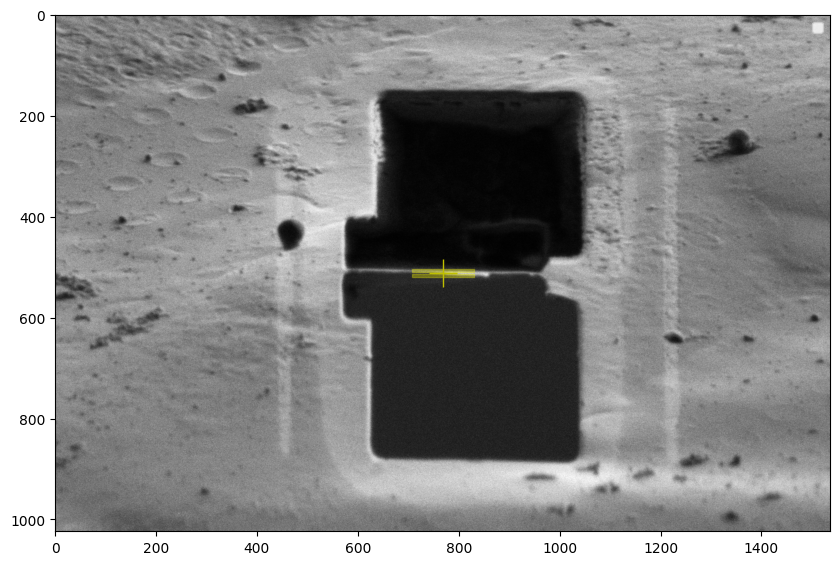

In [9]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

In [10]:
def create_milling_bitmap_array(
    gis_m: NDArray[np.floating],
    gis_stop_m: float,
    gis_full_power_m: float,
    gis_resolution_m: typing.Union[float, None] = None,
    bitmap_resolution_m: typing.Union[float, None] = None,
    dtype: DTypeLike = np.uint8,
    nan_value: float = 0,
) -> NDArray[typing.Any]:
    """
    Strength multiplier should be between 0 and 1

    If bitmap_resolution_m and gis_resolution_m are None, no pixel interpolation is used.
    """
    dt = np.dtype(dtype)

    assert np.issubdtype(dt, np.integer), "Only integer dtypes accepted"

    n = len(gis_m)
    if gis_resolution_m is None and bitmap_resolution_m is None:
        factor = 1
    elif gis_full_power_m is not None and bitmap_resolution_m is not None:
        factor = bitmap_resolution_m / gis_resolution_m
    else:
        raise TypeError(
            "gis_resolution_m and bitmap_resolution_m must both be None or floats, the types cannot be mixed"
        )

    x = np.linspace(0, n - 1, (n - 1) * factor + 1)
    gis_m = gis_m.copy()
    gis_m[np.isnan(gis_m)] = nan_value
    interpolated = np.interp(x, range(n), gis_m)

    # Rescale to uint8 (clips to 0 at gis_stop_m and 255 at gis_full_power_m)
    rescaled = (
        np.round(
            np.interp(
                interpolated,
                (gis_stop_m, gis_full_power_m),
                (np.iinfo(dt).min, np.iinfo(dt).max),
            )
        )
        .astype(dt)
        .reshape(1, -1)
    )

    return rescaled

2025-01-06 18:34:28,838 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2025-01-06 18:34:28,873 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2025-01-06 18:34:30,422 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2025-01-06 18:34:30,463 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:1.3020833333333335e-08
2025-01-06 18:34:31,204 — root — INFO — measure_GIS:118 — window_size_px: 7
2025-01-06 18:34:31,211 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()


C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\code\adaptive_polish\src\adaptive_polish\gis_measurement.py:80: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  mask_largest_only = skimage.morphology.remove_small_objects(
C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\code\adaptive_polish\src\adaptive_polish\gis_measurement.py:148: RuntimeWarning: All-NaN slice encountered
  GIS_windowed = np.nanmedian(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)


Lamella width is 3.525390625e-05 m


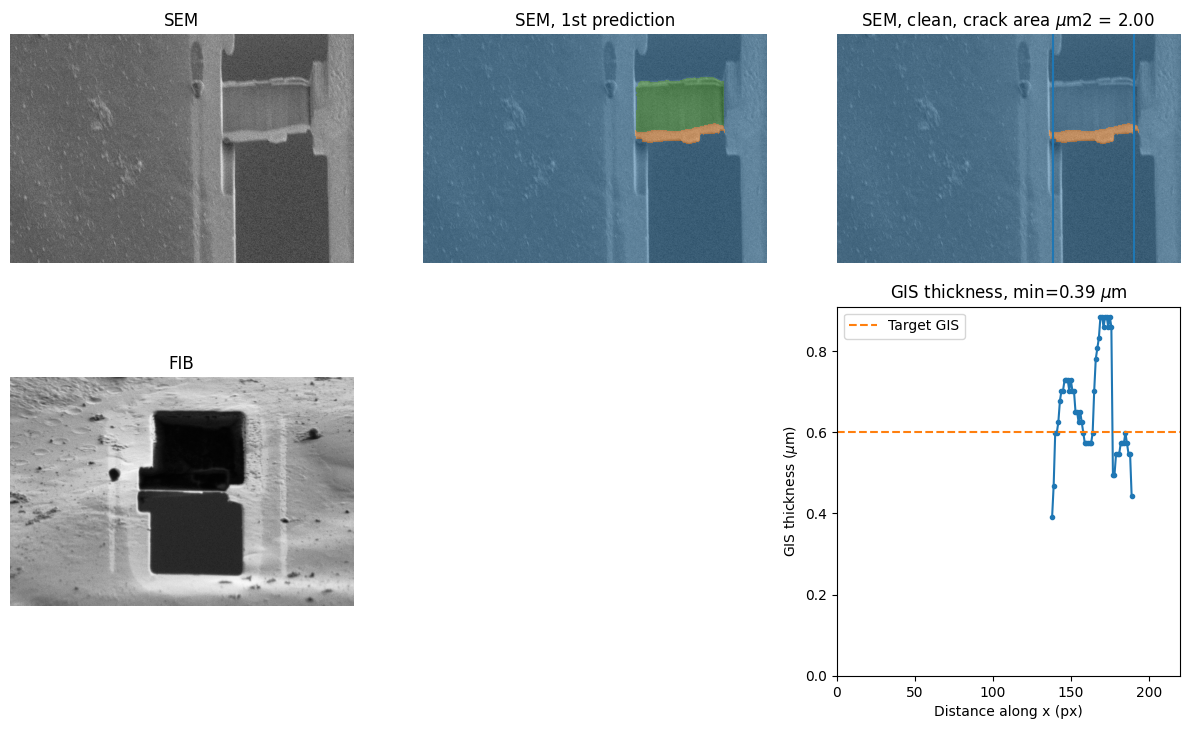

In [11]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = gm.measure_GIS(mask_gis_clean=clean_prediction, window_size_m=1e-7, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    crack_area_m2=float(settings.protocol["adaptive_polish"]["max_crack_area_m2"]),
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
)
lamella_width = (xlims[1] - xlims[0]) * ib_image.metadata.pixel_size.x
print(f"Lamella width is {lamella_width} m")

In [34]:
bitmap = PIL.Image.fromarray(create_milling_bitmap_array(
    gis_m=gis_thickness_m,
    gis_stop_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]),
    gis_full_power_m=float(settings.protocol["adaptive_polish"]["gis_stop_m"]) * 4,
))

In [35]:
with tempfile.TemporaryFile() as tmp_f:
    bitmap.save(tmp_f, format="BMP")
    # Place pattern on image from edited pattern
    ap_milling_protocol = deepcopy(settings.protocol["milling"]["lamella"]["stages"][-1])
    ap_milling_protocol["lamella_width"] = lamella_width
    ap_milling_protocol["hfw"] = 4e-05
    ap_milling_protocol["trench_height"] = 5e-7
    ap_milling_protocol["name"] = "Adjusted adaptive polishing"
    ap_milling_protocol["type"] = "bitmap"
    ap_milling_protocol["path"] = tmp_f.name
    if settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adaptive polishing":
        settings.protocol["milling"]["lamella"]["stages"].append(ap_milling_protocol)
    elif settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adjusted adaptive polishing":
        settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
    stages = get_milling_stages("lamella", settings.protocol["milling"])
    fig = draw_milling_patterns(ib_image, stages)

KeyError: 'width'